🔴 RISK LAYER 3: EEI THRESHOLD VALIDATION

Purpose: Identify shipments exceeding $2,500 under NLR
Regulatory Basis: 15 CFR Part 30 (Electronic Export Information)

📦 Analyzing 5,000 shipments...

📊 RESULTS:
   ┌─ Shipments exceeding $2,500 under NLR: 2,211
   ├─ Defect Rate: 44.22%
   ├─ Total value at risk: $1,417,623,062.12
   └─ Average value per violation: $641,168.28

📊 ANALYSIS BY LICENSE TYPE:


,Total Shipments,EEI Violations,Avg Value,Max Value,Total Value,Violation Rate %
license_type,,,,,,
EXCEPTION,993,0,645011.54,2417077.26,6.404965e+08,0.00
LICENSE,1789,0,620925.52,2445329.70,1.110836e+09,0.00
NLR,2218,2211,639148.49,2394468.30,1.417631e+09,99.68



🔍 SAMPLE EEI VIOLATIONS:

   ┌─ Shipment: EXP-100002
   ├─ Total Value: $122,850.74
   ├─ Quantity: 457 @ $268.82
   ├─ License: NLR (NLR)
   ├─ Business Unit: US-IndustrialEquipment
   ├─ Destination: IN
   └─ Port: LOS ANGELES

   ┌─ Shipment: EXP-100006
   ├─ Total Value: $810,128.64
   ├─ Quantity: 384 @ $2,109.71
   ├─ License: NLR (NLR)
   ├─ Business Unit: US-ConsumerElectronics
   ├─ Destination: MX
   └─ Port: SEATTLE

   ┌─ Shipment: EXP-100007
   ├─ Total Value: $272,477.40
   ├─ Quantity: 156 @ $1,746.65
   ├─ License: NLR (NLR)
   ├─ Business Unit: US-Pharmaceuticals
   ├─ Destination: CN
   └─ Port: SEATTLE

   ┌─ Shipment: EXP-100009
   ├─ Total Value: $1,712,489.13
   ├─ Quantity: 407 @ $4,207.59
   ├─ License: NLR (NLR)
   ├─ Business Unit: US-MedicalDevices
   ├─ Destination: SG
   └─ Port: SEATTLE

   ┌─ Shipment: EXP-100010
   ├─ Total Value: $1,320,148.53
   ├─ Quantity: 333 @ $3,964.41
   ├─ License: NLR (NLR)
   ├─ Business Unit: US-Pharmaceuticals
   ├─ Destina

,Violations_Count,Total_Shipments,Violation_Rate_Pct
shipment_month,,,
2025-07,147,349,42.12
2025-08,182,415,43.86
2025-09,169,401,42.14
2025-10,199,433,45.96
2025-11,191,430,44.42
2025-12,205,465,44.09
2026-01,191,384,49.74
2026-02,169,395,42.78
2026-03,189,402,47.01



📈 RECENT TREND (Last 6 months):
   2026-02: 42.78% █████████████████████
   2026-03: 47.01% ███████████████████████
   2026-04: 44.25% ██████████████████████
   2026-05: 42.53% █████████████████████
   2026-06: 42.20% █████████████████████
   2026-07: 41.94% ████████████████████

📊 EEI VIOLATIONS BY BUSINESS UNIT:


,Business Unit,Total Shipments,EEI Violations,Total Value,Violation Rate %
0,US-AerospaceParts,735,332,4.713519e+08,45.17
3,US-MedicalDevices,1239,557,8.121318e+08,44.96
4,US-Pharmaceuticals,478,213,2.948135e+08,44.56
1,US-ConsumerElectronics,1582,693,9.824572e+08,43.81
2,US-IndustrialEquipment,966,416,6.082091e+08,43.06



📊 EEI VIOLATIONS BY PORT OF EXIT:


,Port of Exit,Total Shipments,EEI Violations,Total Value,Violation Rate %
3,MIAMI,715,326,4.610282e+08,45.59
1,HOUSTON,713,321,4.651421e+08,45.02
6,SEATTLE,722,325,4.691555e+08,45.01
2,LOS ANGELES,722,323,4.411995e+08,44.74
0,CHICAGO O'HARE,699,306,4.509616e+08,43.78
5,NEWARK,712,307,4.677804e+08,43.12
4,NEW YORK,717,303,4.136962e+08,42.26


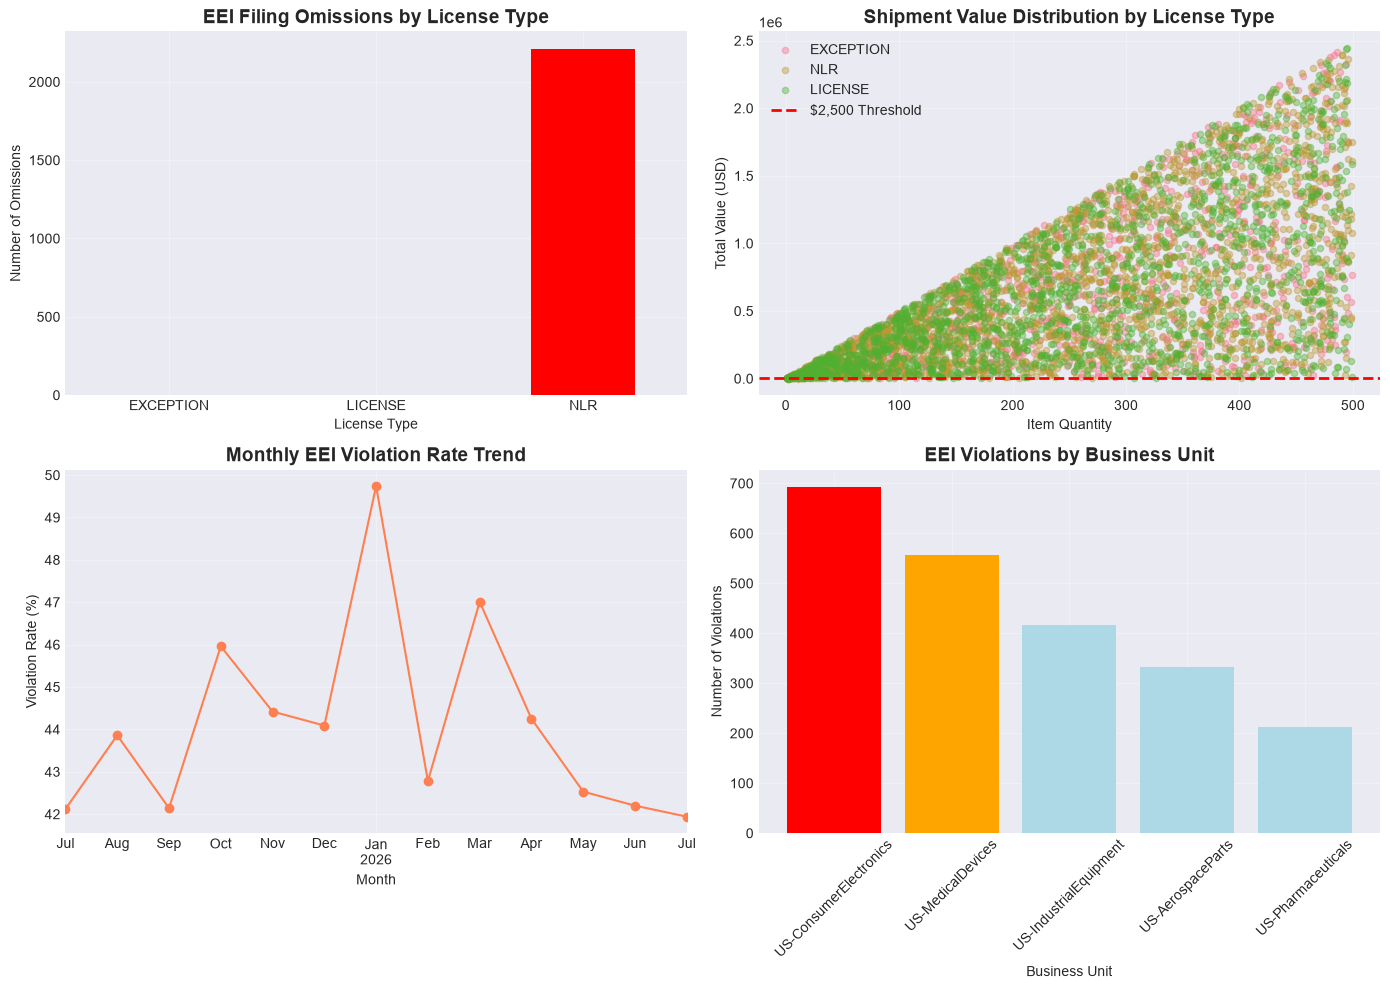


💾 Saved: output/risk_layer3_eei_threshold.png

💾 Saved: us_export_compliance_data_layer3.csv

✅ RISK LAYER 3 COMPLETE!


In [1]:
# %% [markdown]
# # 🔴 Risk Layer 3: EEI Threshold Validation
# 
# **Purpose**: Identify high-value NLR shipments requiring EEI filing
# 
# **Regulatory Basis**: 15 CFR Part 30 (Foreign Trade Regulations)
# 
# **Key Question**: Are we failing to file EEI for high-value NLR shipments?

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("🔴 RISK LAYER 3: EEI THRESHOLD VALIDATION")
print("="*70)
print("\nPurpose: Identify shipments exceeding $2,500 under NLR")
print("Regulatory Basis: 15 CFR Part 30 (Electronic Export Information)")

# %% [code]
# Load dataset with previous layers
df = pd.read_csv('us_export_compliance_data_layer2.csv', parse_dates=['shipment_date', 'clearance_date'])

print(f"\n📦 Analyzing {len(df):,} shipments...")

# %% [markdown]
# ## EEI Threshold Logic
# 
# **Rule**: Any single line item valued over $2,500 under NLR must file EEI
# - `total_value_usd > 2500`
# - `license_type == 'NLR'`

# %% [code]
# Apply EEI threshold logic
EEI_THRESHOLD = 2500
df['eei_filing_required'] = (
    (df['total_value_usd'] > EEI_THRESHOLD) & 
    (df['license_type'] == 'NLR')
)

# Count violations
eei_violations = df['eei_filing_required'].sum()
eei_violation_rate = (eei_violations / len(df)) * 100
eei_total_value = df[df['eei_filing_required']]['total_value_usd'].sum()
eei_avg_value = df[df['eei_filing_required']]['total_value_usd'].mean()

print(f"\n📊 RESULTS:")
print(f"   ┌─ Shipments exceeding ${EEI_THRESHOLD:,} under NLR: {eei_violations:,}")
print(f"   ├─ Defect Rate: {eei_violation_rate:.2f}%")
print(f"   ├─ Total value at risk: ${eei_total_value:,.2f}")
print(f"   └─ Average value per violation: ${eei_avg_value:,.2f}")

# %% [markdown]
# ## Analysis by License Type

# %% [code]
license_analysis = df.groupby('license_type').agg({
    'shipment_id': 'count',
    'eei_filing_required': 'sum',
    'total_value_usd': ['mean', 'max', 'sum']
}).round(2)

license_analysis.columns = ['Total Shipments', 'EEI Violations', 
                           'Avg Value', 'Max Value', 'Total Value']
license_analysis['Violation Rate %'] = (
    license_analysis['EEI Violations'] / license_analysis['Total Shipments'] * 100
).round(2)

print("\n📊 ANALYSIS BY LICENSE TYPE:")
display(license_analysis)

# %% [markdown]
# ## Examine Violations

# %% [code]
if eei_violations > 0:
    print("\n🔍 SAMPLE EEI VIOLATIONS:")
    sample_eei = df[df['eei_filing_required']][
        ['shipment_id', 'total_value_usd', 'license_type', 
         'item_quantity', 'unit_value_usd', 'exporter_business_unit',
         'consignee_country', 'port_of_exit']
    ].head(5)
    
    for idx, row in sample_eei.iterrows():
        print(f"\n   ┌─ Shipment: {row['shipment_id']}")
        print(f"   ├─ Total Value: ${row['total_value_usd']:,.2f}")
        print(f"   ├─ Quantity: {row['item_quantity']} @ ${row['unit_value_usd']:,.2f}")
        print(f"   ├─ License: {row['license_type']} (NLR)")
        print(f"   ├─ Business Unit: {row['exporter_business_unit']}")
        print(f"   ├─ Destination: {row['consignee_country']}")
        print(f"   └─ Port: {row['port_of_exit']}")

# %% [markdown]
# ## Time-Based Analysis

# %% [code]
# Monthly violation rate
df['shipment_month'] = df['shipment_date'].dt.to_period('M')
monthly_eei = df.groupby('shipment_month').agg({
    'eei_filing_required': ['sum', 'count']
}).round(4)

monthly_eei.columns = ['Violations_Count', 'Total_Shipments']
monthly_eei['Violation_Rate_Pct'] = (monthly_eei['Violations_Count'] / monthly_eei['Total_Shipments'] * 100).round(2)

print("\n📅 MONTHLY EEI VIOLATION RATE:")
display(monthly_eei)

# Show recent trend
print("\n📈 RECENT TREND (Last 6 months):")
for month, row in monthly_eei.tail(6).iterrows():
    rate = row['Violation_Rate_Pct']
    bar = '█' * int(rate / 2)
    print(f"   {month}: {rate:5.2f}% {bar}")

# %% [markdown]
# ## Analysis by Business Unit

# %% [code]
bu_eei = df.groupby('exporter_business_unit').agg({
    'shipment_id': 'count',
    'eei_filing_required': 'sum',
    'total_value_usd': 'sum'
}).reset_index()

bu_eei.columns = ['Business Unit', 'Total Shipments', 'EEI Violations', 'Total Value']
bu_eei['Violation Rate %'] = (bu_eei['EEI Violations'] / bu_eei['Total Shipments'] * 100).round(2)
bu_eei = bu_eei.sort_values('Violation Rate %', ascending=False)

print("\n📊 EEI VIOLATIONS BY BUSINESS UNIT:")
display(bu_eei)

# %% [markdown]
# ## Analysis by Port of Exit

# %% [code]
port_eei = df.groupby('port_of_exit').agg({
    'shipment_id': 'count',
    'eei_filing_required': 'sum',
    'total_value_usd': 'sum'
}).reset_index()

port_eei.columns = ['Port of Exit', 'Total Shipments', 'EEI Violations', 'Total Value']
port_eei['Violation Rate %'] = (port_eei['EEI Violations'] / port_eei['Total Shipments'] * 100).round(2)
port_eei = port_eei.sort_values('Violation Rate %', ascending=False)

print("\n📊 EEI VIOLATIONS BY PORT OF EXIT:")
display(port_eei)

# %% [markdown]
# ## Visualization

# %% [code]
# Create output folder if it doesn't exist
if not os.path.exists('output'):
    os.makedirs('output')
    print("✅ Created output folder")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Violations by license type
violation_data = license_analysis['EEI Violations']
colors = ['red' if idx == 'NLR' else 'lightblue' for idx in violation_data.index]
violation_data.plot(kind='bar', ax=axes[0,0], color=colors)
axes[0,0].set_title('EEI Filing Omissions by License Type', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('License Type')
axes[0,0].set_ylabel('Number of Omissions')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].grid(True, alpha=0.3)

# 2. Scatter plot - value distribution
for license_type in df['license_type'].unique():
    subset = df[df['license_type'] == license_type]
    axes[0,1].scatter(subset['item_quantity'], subset['total_value_usd'], 
                    alpha=0.4, label=license_type, s=20)

# Add threshold line
axes[0,1].axhline(y=2500, color='red', linestyle='--', linewidth=2, label='$2,500 Threshold')
axes[0,1].set_title('Shipment Value Distribution by License Type', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Item Quantity')
axes[0,1].set_ylabel('Total Value (USD)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Monthly violation trend
monthly_eei['Violation_Rate_Pct'].plot(kind='line', ax=axes[1,0], marker='o', color='coral')
axes[1,0].set_title('Monthly EEI Violation Rate Trend', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Violation Rate (%)')
axes[1,0].grid(True, alpha=0.3)

# 4. Violations by business unit
bu_eei_sorted = bu_eei.sort_values('EEI Violations', ascending=False).head(10)
colors_bu = ['red' if i == 0 else 'orange' if i == 1 else 'lightblue' for i in range(len(bu_eei_sorted))]
axes[1,1].bar(bu_eei_sorted['Business Unit'], bu_eei_sorted['EEI Violations'], color=colors_bu)
axes[1,1].set_title('EEI Violations by Business Unit', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Business Unit')
axes[1,1].set_ylabel('Number of Violations')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/risk_layer3_eei_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved: output/risk_layer3_eei_threshold.png")

# %% [code]
# Save the enhanced dataset
df.to_csv('us_export_compliance_data_layer3.csv', index=False)
print("\n💾 Saved: us_export_compliance_data_layer3.csv")

print("\n" + "="*70)
print("✅ RISK LAYER 3 COMPLETE!")
print("="*70)